# Prism-AI Coeffient Generator Tool

Generate activation function coefficients for Prism-AI experiments

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from prism.prism_math.activation_coefs import \
    visual_test_alpha_coefs_tanh, \
    visual_test_alpha_coefs_sech, \
    visual_test_alpha_coefs_sech2, \
    visual_test_alpha_coefs_relu, \
    compute_eta_error_tanh_analytic, compute_eta_error_tanh_approx_large_tau, \
    compute_eta_error_sech_analytic, compute_eta_error_sech_approx_large_sigma, \
    compute_eta_error_relu_analytic, compute_eta_error_relu_approx_large_sigma

from prism.prism_math.activation_coefs import get_alpha_coefs

from prism.prism_math.polynomials import polyval_cpu

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Palatino'],
    'font.size': 16
})

## Smoke Test the Alpha Coefficients Generators

Test the coefficient generators before doing large coefficient generation runs.


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


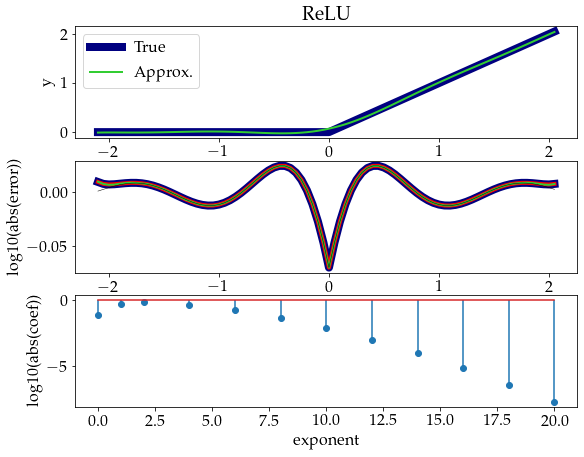

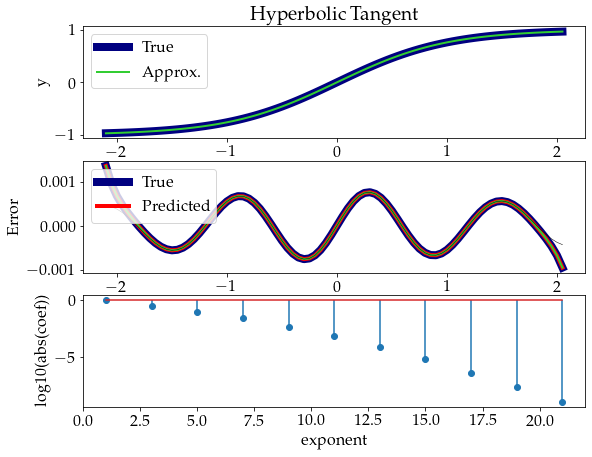

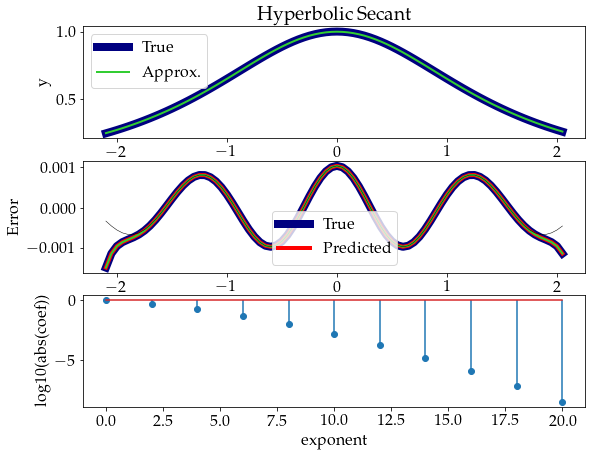

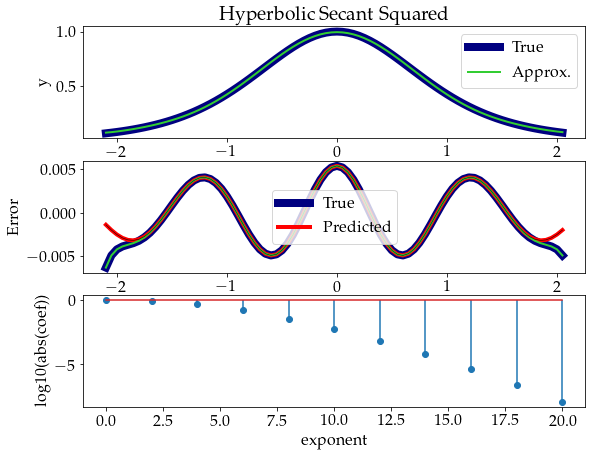

In [2]:
# Rectified Linear Unit
visual_test_alpha_coefs_relu()

# Hyperbolic Tangent
visual_test_alpha_coefs_tanh()

# Hyperbolic Secant
visual_test_alpha_coefs_sech()

# Hyperbolic Secant Squared
visual_test_alpha_coefs_sech2()


## Generate the Alpha Coefficients for the Hyberbolic Tangent

Here we generate and save coefficients for the hyperbolic tangent given the user set parameters.


In [3]:
# Expansion parameters
v_max = 2
big_m = 10
dps = 100


In [4]:
alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='tanh',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=True, silent=False,
        save_str='vmax{}_bigm{}'.format(v_max, big_m))

Generated tanh coef. 0.995857717409979642547889278208724433364035025092015319424596421674376486948528982052989248596126028 for exponent 1
Generated tanh coef. -0.312659418910504481644664877463937990939196531069523617582057921791646719486802934817480183259697624 for exponent 3
Generated tanh coef. 0.09978836911061808187224192384850814823952347289654824497472721008754752724499299899902285309006784465 for exponent 5
Generated tanh coef. -0.02490853574115353713980589601995604619246973286055635424348470342833803303778577432192230709906195822 for exponent 7
Generated tanh coef. 0.004655566326950181556172480815410322373339023782013175466647686736335277036882891598227308524112893215 for exponent 9
Generated tanh coef. -0.0006543436497377999763810476845668087186519032538995174854603451371651041528908686701267428745385107372 for exponent 11
Generated tanh coef. 0.00007053577412574532094820141494851628933103592077907102547682999498124266483637855485679511862423376462 for exponent 13
Generated tan

## Test the Alpha Coefficients for the Hyperbolic Tangent

Here we test the generated coefficients for the hyperbolic tangent.


In [5]:
v = np.linspace(-1.1*v_max, 1.1*v_max, 30)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = np.tanh(v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_tanh_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_tanh_approx_large_tau(v, big_m, v_max)

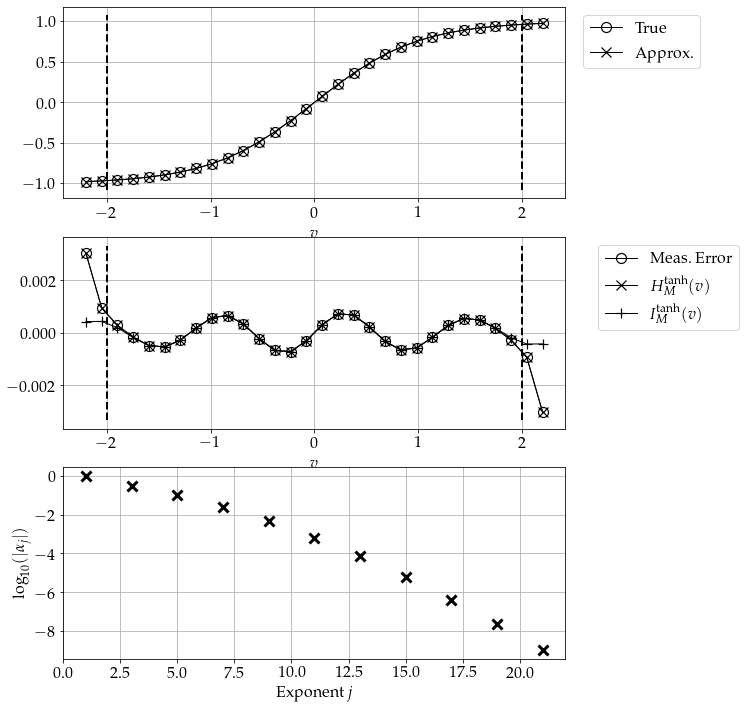

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(9,12))

my_ms = 10
my_mew = 1.2

# Plot the function and the approximation
axs[0].plot(
    v, y_true,
    lw=1, color='black',
    marker='o', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[0].plot(
    v, y,
    lw=1, color='black',
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[0].set_xlabel('$$v$$')
axs[0].legend((
    'True', 'Approx.'),
    prop={"size":16},
    bbox_to_anchor=(1.02, 1))
axs[0].grid()

# Plot lines to mark domain of convergence
axs[0].vlines(
    [-v_max, v_max],
    axs[0].get_ylim()[0],
    axs[0].get_ylim()[1],
    lw=2, ls='--', color='black')

# Plot the error formulas
axs[1].plot(
    v, error,
    lw=1, color='black',
    marker='o', ms=my_ms,
    mfc='none', mec='black', mew=my_mew
    )

axs[1].plot(
    v, error_predicted_analytical,
    lw=1, color='black',
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[1].plot(
    v, error_predicted_approx,
    lw=1, color='black',
    marker='+', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[1].set_xlabel('$$v$$')
axs[1].legend((
    '$$\mathrm{Meas.\ Error}$$',
    '$$H_M^{\mathrm{tanh}}(v)$$',
    '$$I_M^{\mathrm{tanh}}(v)$$'),
    prop={"size":16},
    bbox_to_anchor=(1.05, 1))
axs[1].grid()

# Plot lines to mark domain of convergence
axs[1].vlines(
    [-v_max, v_max],
    axs[1].get_ylim()[0],
    axs[1].get_ylim()[1],
    lw=2, ls='--', color='black')

# Plot the coefficients themselves
axs[2].plot(
    exponents, np.log10(np.abs(alpha_coefs_float64)),
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=3,
    linestyle='none')
axs[2].set_xlabel('$$\mathrm{Exponent}\\ j$$')
axs[2].set_ylabel('$$\mathrm{log}_{10}(|\\alpha_j|)$$')
axs[2].grid()

## Generate the Alpha Coefficients for the Hyberbolic Secant

Here we generate and save coefficients for the hyperbolic secant given the user set parameters.


In [7]:
# Expansion parameters
v_max = 2
big_m = 10
dps = 100


In [8]:
alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='sech',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=True, silent=False,
        save_str='vmax{}_bigm{}'.format(v_max, big_m))

Generated sech coef. 0.9989611448546315636939237619753394758966542324215210587315531686093073062704783922478147640438336058 for exponent 0
Generated sech coef. -0.4859393010361700758196182560959287545328854019585140163916882661786691282494066693272491441285594995 for exponent 2
Generated sech coef. 0.1742258751976904311770236345606101302507245877570701137411914037336800117516445465898409456551812736 for exponent 4
Generated sech coef. -0.04799768190775880568442872547058233195911944771428124924319640025949399742347079182721021396683360259 for exponent 6
Generated sech coef. 0.009806353050008670164924739396750419300487131528489800679734629750245866102094008464383067212623872559 for exponent 8
Generated sech coef. -0.001484066268010612387060031956430746491993715580369059512996556376331173132091524566405319848745611628 for exponent 10
Generated sech coef. 0.0001695414708477961311351869656400806913210020589952259412061341527974637452244318347825617670377778906 for exponent 12
Generated sech

## Test the Alpha Coefficients for the Hyperbolic Secant

Here we test the generated coefficients for the hyperbolic secant.


In [9]:
v = np.linspace(-1.1*v_max, 1.1*v_max, 30)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 1/np.cosh(v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_sech_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_sech_approx_large_sigma(v, big_m, v_max)

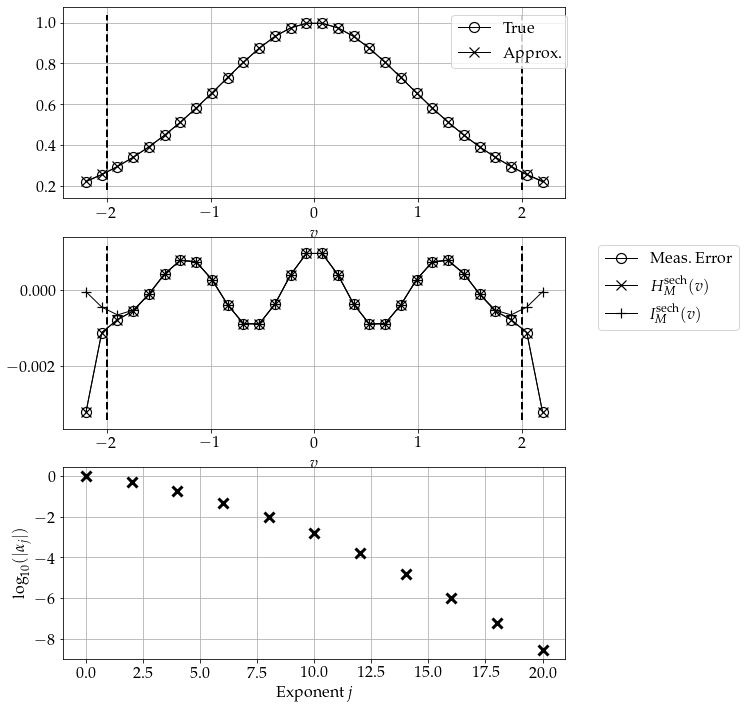

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(9,12))

my_ms = 10
my_mew = 1.2

# Plot the function and the approximation
axs[0].plot(
    v, y_true,
    lw=1, color='black',
    marker='o', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[0].plot(
    v, y,
    lw=1, color='black',
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[0].set_xlabel('$$v$$')
axs[0].legend((
    'True', 'Approx.'),
    prop={"size":16},
    bbox_to_anchor=(1.02, 1))
axs[0].grid()

# Plot lines to mark domain of convergence
axs[0].vlines(
    [-v_max, v_max],
    axs[0].get_ylim()[0],
    axs[0].get_ylim()[1],
    lw=2, ls='--', color='black')

# Plot the error formulas
axs[1].plot(
    v, error,
    lw=1, color='black',
    marker='o', ms=my_ms,
    mfc='none', mec='black', mew=my_mew
    )

axs[1].plot(
    v, error_predicted_analytical,
    lw=1, color='black',
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[1].plot(
    v, error_predicted_approx,
    lw=1, color='black',
    marker='+', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[1].set_xlabel('$$v$$')
axs[1].legend((
    '$$\mathrm{Meas.\ Error}$$',
    '$$H_M^{\mathrm{sech}}(v)$$',
    '$$I_M^{\mathrm{sech}}(v)$$'),
    prop={"size":16},
    bbox_to_anchor=(1.05, 1))
axs[1].grid()

# Plot lines to mark domain of convergence
axs[1].vlines(
    [-v_max, v_max],
    axs[1].get_ylim()[0],
    axs[1].get_ylim()[1],
    lw=2, ls='--', color='black')

# Plot the coefficients themselves
axs[2].plot(
    exponents, np.log10(np.abs(alpha_coefs_float64)),
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=3,
    linestyle='none')
axs[2].set_xlabel('$$\mathrm{Exponent}\\ j$$')
axs[2].set_ylabel('$$\mathrm{log}_{10}(|\\alpha_j|)$$')
axs[2].grid()

## Generate the Alpha Coefficients for the ReLU

Here we generate and save coefficients for the ReLU given the user set parameters.

In [11]:
# Expansion params
v_max = 2
big_m = 10
dps = 100

In [12]:
alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='relu',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=True, silent=False,
        save_str='vmax{}_bigm{}'.format(v_max, big_m))

Generated relu coef. 0.07031161865953066547483619296334361221309075767265824194513317697245425288955861880194375552654973084 for exponent 0
Generated relu coef. 0.7205152261745277874035171107683557138718351432860608564666291566695277169807269428415760101130578647 for exponent 2
Generated relu coef. -0.4101915642318966534715243174242442385122355211060962947045064615371643658991487143716567092090346026 for exponent 4
Generated relu coef. 0.1681368020318599048194713943748887856164855884184623064685009851747544438021539593910166237740554303 for exponent 6
Generated relu coef. -0.04395343110073508346352565608721827219821263846696893633367780880965295592918122001075128509614117366 for exponent 8
Generated relu coef. 0.007784878993454897801548416077278857832759852641360801978592042228283118196407512932594360707106526935 for exponent 10
Generated relu coef. -0.0009889488322341037379040466137912963801947317478583055400779235471294408306094225114226252216342647322 for exponent 12
Generated relu 

## Test the Alpha Coefficient Generators for the ReLU

Here we test the generated coefficients for the ReLU.


In [13]:
v = np.linspace(-1.1*v_max, 1.1*v_max, 40)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 0.5*(np.abs(v) + v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_relu_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_relu_approx_large_sigma(v, big_m, v_max)

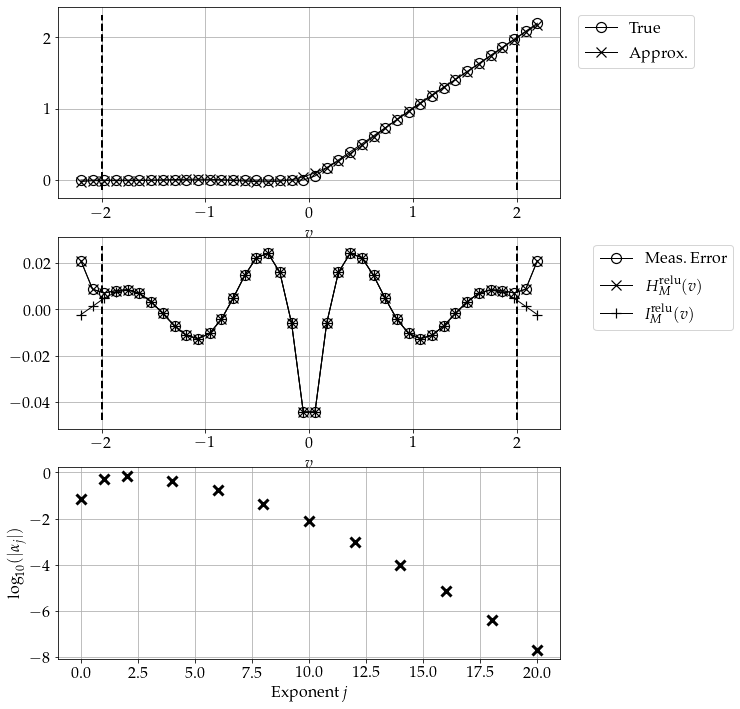

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(9,12))

my_ms = 10
my_mew = 1.2

# Plot the function and the approximation
axs[0].plot(
    v, y_true,
    lw=1, color='black',
    marker='o', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[0].plot(
    v, y,
    lw=1, color='black',
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[0].set_xlabel('$$v$$', fontsize=16)
axs[0].legend((
    'True', 'Approx.'),
    prop={"size":16},
    bbox_to_anchor=(1.02, 1))
axs[0].grid()

# Plot lines to mark domain of convergence
axs[0].vlines(
    [-v_max, v_max],
    axs[0].get_ylim()[0],
    axs[0].get_ylim()[1],
    lw=2, ls='--', color='black')

# Plot the error formulas
axs[1].plot(
    v, error,
    lw=1, color='black',
    marker='o', ms=my_ms,
    mfc='none', mec='black', mew=my_mew
    )

axs[1].plot(
    v, error_predicted_analytical,
    lw=1, color='black',
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[1].plot(
    v, error_predicted_approx,
    lw=1, color='black',
    marker='+', ms=my_ms,
    mfc='none', mec='black', mew=my_mew)

axs[1].set_xlabel('$$v$$')
axs[1].legend((
    '$$\mathrm{Meas.\ Error}$$',
    '$$H_M^{\mathrm{relu}}(v)$$',
    '$$I_M^{\mathrm{relu}}(v)$$'),
    prop={"size":16},
    bbox_to_anchor=(1.05, 1))
axs[1].grid()

# Plot lines to mark domain of convergence
axs[1].vlines(
    [-v_max, v_max],
    axs[1].get_ylim()[0],
    axs[1].get_ylim()[1],
    lw=2, ls='--', color='black')

# Plot the coefficients themselves
axs[2].plot(
    exponents, np.log10(np.abs(alpha_coefs_float64)),
    marker='x', ms=my_ms,
    mfc='none', mec='black', mew=3,
    linestyle='none')
axs[2].set_xlabel('$$\mathrm{Exponent}\\ j$$')
axs[2].set_ylabel('$$\mathrm{log}_{10}(|\\alpha_j|)$$')
axs[2].grid()